In [1]:
from hduq.cnhu.cgh import *

In [2]:
g = CGH(100)
g.clear_modes()
g.add_modes(HG(0, 0) + HG(0, 1), 500, 0)


resetting...


In [3]:
g.freeze()
g

this CGH instance is now frozen


========================= CGH TASK GRAPH =========================
 Sigma: 100;    Frozen: True;    Quiet: False
------------------------------------------------------------------
 ID   | (nx, ny)       | Mode(order_1, order_2, x_shift, y_shift)
------------------------------------------------------------------
 0    | (500, 0)       | HG(0, 0, 0.0, 0.0) + HG(0, 1, 0.0, 0.0)

In [4]:
g1 = CGH(100)
g1.add_modes(HG(0, 0), 500, 0)

g1.freeze()
g1.cal(x_shift_fast=500)

this CGH instance is now frozen


C:\Users\Administrator\Desktop\hduq\src\hduq\cnhu\cgh.py:217: ComplexWarning: Casting complex values to real discards the imaginary part
  self.cgh = cgh.astype(np.uint8)


In [5]:
g2 = CGH(100)
g2.add_modes(HG(0, 0, x_shift=500), 500, 0)

g2.cal()

In [6]:
g3 = CGH(100)
g3.add_modes(HG(0, 0), 500, 0)

g3.cal()

In [7]:
from hcn.preamble import *
np.allclose(g1.cgh, g2.cgh, atol=10)

False

In [12]:
def thin_lens(U_input):
    Ny, Nx = U_input.shape
    N = max(Nx, Ny)
    U_pad = np.zeros((N, N), dtype=complex)

    start_y = (N - Ny) // 2
    start_x = (N - Nx) // 2
    U_pad[start_y : start_y + Ny, start_x : start_x + Nx] = U_input

    U_focal_pad = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(U_pad)))
    U_focal = U_focal_pad[start_y : start_y + Ny, start_x : start_x + Nx]

    return U_focal

In [28]:
g3.cgh * np.exp(-2j * pi * (SLM.x * 1000))

array([[127.-9.47430282e-08j, 127.-8.57734900e-08j, 127.-7.68039518e-08j,
        ..., 127.+6.78344136e-08j, 127.+7.68039518e-08j,
        127.+8.57734900e-08j],
       [127.-9.47430282e-08j, 127.-8.57734900e-08j, 127.-7.68039518e-08j,
        ..., 127.+6.78344136e-08j, 127.+7.68039518e-08j,
        127.+8.57734900e-08j],
       [127.-9.47430282e-08j, 127.-8.57734900e-08j, 127.-7.68039518e-08j,
        ..., 127.+6.78344136e-08j, 127.+7.68039518e-08j,
        127.+8.57734900e-08j],
       ...,
       [127.-9.47430282e-08j, 127.-8.57734900e-08j, 127.-7.68039518e-08j,
        ..., 127.+6.78344136e-08j, 127.+7.68039518e-08j,
        127.+8.57734900e-08j],
       [127.-9.47430282e-08j, 127.-8.57734900e-08j, 127.-7.68039518e-08j,
        ..., 127.+6.78344136e-08j, 127.+7.68039518e-08j,
        127.+8.57734900e-08j],
       [127.-9.47430282e-08j, 127.-8.57734900e-08j, 127.-7.68039518e-08j,
        ..., 127.+6.78344136e-08j, 127.+7.68039518e-08j,
        127.+8.57734900e-08j]], shape=(1080, 19

TypeError: Image data of dtype complex128 cannot be converted to float

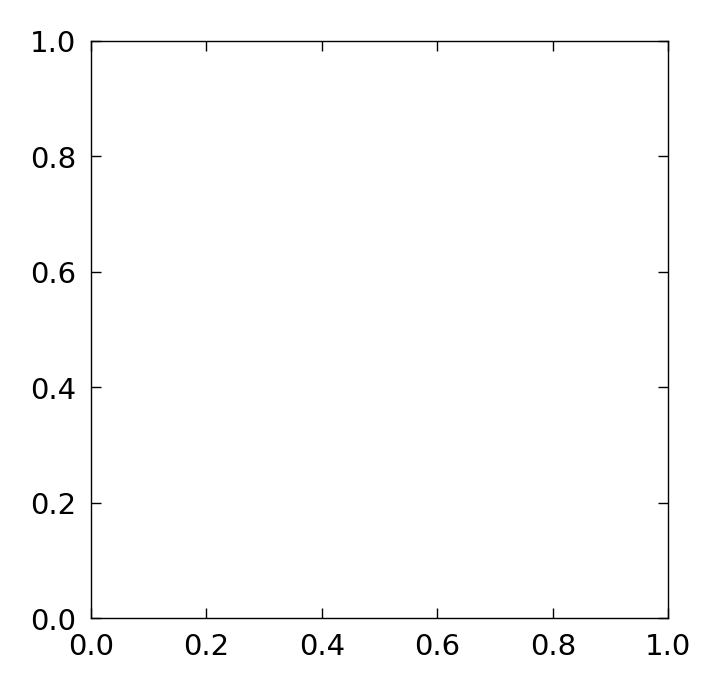

In [ ]:
plt.imshow(np.abs(thin_lens(thin_lens(g3.cgh * np.exp(-2j * pi * (SLM.x * 0))))))

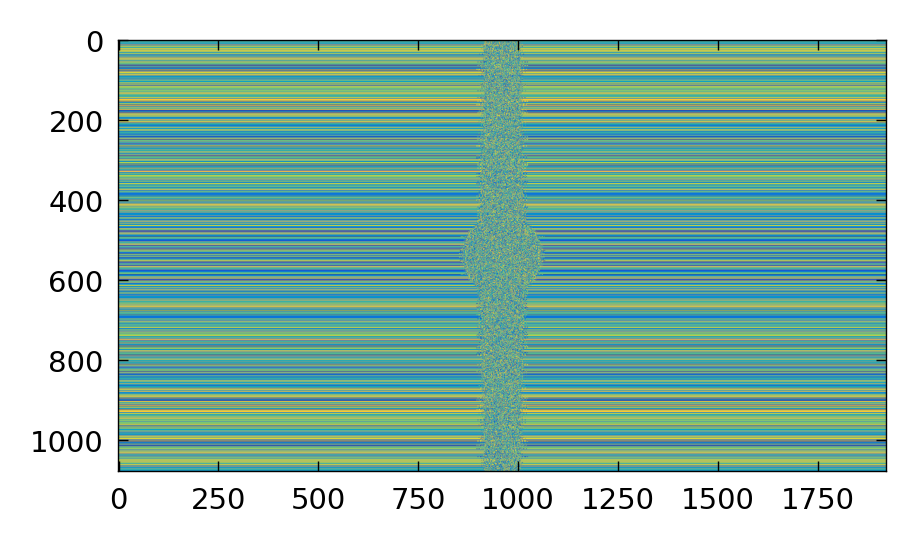

In [8]:
plt.imshow(g1.cgh)
# plt.imshow()

In [9]:
np.all(g1.cgh == g2.cgh)

np.False_